##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [84]:
import os
import numpy as np
import tensorflow as tf

import keras
import keras_cv

import matplotlib.pyplot as plt

In [85]:
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor",
]

CLASS_TO_ID = {name: i for i, name in enumerate(VOC_CLASSES)}
ID_TO_CLASS = {i: name for i, name in enumerate(VOC_CLASSES)}

selected = ["dog", "bus", "sofa", "cat", "chair"]
print("Selected classes (name -> id):")
for c in selected:
    print(f"- {c:5s} -> {CLASS_TO_ID[c]}")

Selected classes (name -> id):
- dog   -> 11
- bus   -> 5
- sofa  -> 17
- cat   -> 7
- chair -> 8


In [86]:
IMAGE_URLS = {
    "dog":   "https://upload.wikimedia.org/wikipedia/commons/6/61/20110425_German_Shepherd_Dog_8505.jpg",
    "bus":   "https://upload.wikimedia.org/wikipedia/commons/5/5e/La_Ferri%C3%A8re_Airoux_86_Bus%26abri_bus_2014.jpg",
    "sofa":  "https://upload.wikimedia.org/wikipedia/commons/a/a1/Moscow_State_University_couch_2014-01_1389530021.JPG",
    "cat":   "https://upload.wikimedia.org/wikipedia/commons/4/4d/Cat_November_2010-1a.jpg",
    "chair": "https://upload.wikimedia.org/wikipedia/commons/9/91/Korean_chair_in_Finland.jpg",
}

expected_labels = list(IMAGE_URLS.keys())
image_urls = [IMAGE_URLS[k] for k in expected_labels]

expected_ids = [CLASS_TO_ID[k] for k in expected_labels]
print("Expected IDs:", dict(zip(expected_labels, expected_ids)))

Expected IDs: {'dog': 11, 'bus': 5, 'sofa': 17, 'cat': 7, 'chair': 8}


In [ ]:
import os, time, random
import urllib.request
from urllib.parse import urlparse

def download_image(url: str, out_dir="/mnt/data/od_images",
                   max_retries=6, base_sleep=1.2) -> str:
   
    os.makedirs(out_dir, exist_ok=True)

    # filename
    path = urlparse(url).path
    fname = os.path.basename(path) or "image.jpg"
    local_path = os.path.join(out_dir, fname)

    # cache hit
    if os.path.exists(local_path) and os.path.getsize(local_path) > 0:
        return local_path

    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/122.0.0.0 Safari/537.36"
        ),
        "Accept": "image/avif,image/webp,image/apng,image/*,*/*;q=0.8",
        "Referer": "https://commons.wikimedia.org/",
    }

    last_err = None
    for attempt in range(max_retries):
        time.sleep(0.6 + random.random() * 0.6)

        try:
            req = urllib.request.Request(url, headers=headers)
            with urllib.request.urlopen(req) as r:
                data = r.read()

            with open(local_path, "wb") as f:
                f.write(data)

            return local_path

        except Exception as e:
            last_err = e

            sleep_s = (base_sleep * (2 ** attempt)) + random.random()
            print(f"[download retry] attempt {attempt+1}/{max_retries} failed: {repr(e)}")
            print(f"  sleeping {sleep_s:.1f}s then retrying...")
            time.sleep(sleep_s)

    raise RuntimeError(f"URL download failed after retries: {url}\nLast error: {repr(last_err)}")


def load_image_as_tensor(path: str) -> tf.Tensor:
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    return tf.cast(img, tf.float32)

In [ ]:
FALLBACK_URLS = {
    "dog": [
        IMAGE_URLS["dog"],
        "https://picsum.photos/seed/dog1/1200/800",
    ],
    "bus": [
        IMAGE_URLS["bus"],
        "https://picsum.photos/seed/bus1/1200/800",
    ],
    "sofa": [
        IMAGE_URLS["sofa"],
        "https://picsum.photos/seed/sofa1/1200/800",
    ],
    "cat": [
        IMAGE_URLS["cat"],
        "https://picsum.photos/seed/cat1/1200/800",
    ],
    "chair": [
        IMAGE_URLS["chair"],
        "https://picsum.photos/seed/chair1/1200/800",
    ],
}

local_paths = []
images = []

for label in expected_labels:
    ok = False
    last_err = None

    for url in FALLBACK_URLS[label]:
        try:
            p = download_image(url)   
            img = load_image_as_tensor(p)
            local_paths.append(p)
            images.append(img)
            ok = True
            break
        except Exception as e:
            last_err = e

    if not ok:
        raise RuntimeError(f"Failed downloading '{label}'. Last error: {repr(last_err)}")

images_uint8 = [tf.cast(tf.clip_by_value(im, 0, 255), tf.uint8).numpy() for im in images]

print("Downloaded files:")
for lbl, p in zip(expected_labels, local_paths):
    print(f"- {lbl:5s}: {p}")

print("Loaded image shapes:", [im.shape for im in images])

Downloaded files:
- dog  : /mnt/data/od_images/20110425_German_Shepherd_Dog_8505.jpg
- bus  : /mnt/data/od_images/La_Ferri%C3%A8re_Airoux_86_Bus%26abri_bus_2014.jpg
- sofa : /mnt/data/od_images/Moscow_State_University_couch_2014-01_1389530021.JPG
- cat  : /mnt/data/od_images/Cat_November_2010-1a.jpg
- chair: /mnt/data/od_images/Korean_chair_in_Finland.jpg
Loaded image shapes: [TensorShape([2820, 4245, 3]), TensorShape([3040, 4880, 3]), TensorShape([2048, 3072, 3]), TensorShape([2397, 1795, 3]), TensorShape([4023, 6035, 3])]


In [93]:
inference_resizing = keras_cv.layers.Resizing(
    640, 640,
    pad_to_aspect_ratio=True,
    bounding_box_format="xywh",
)

In [94]:
PRESET = "yolo_v8_m_pascalvoc"

def load_yolov8_pascalvoc():
    if hasattr(keras_cv.models, "YOLOV8Detector") and hasattr(keras_cv.models.YOLOV8Detector, "from_preset"):
        try:
            model = keras_cv.models.YOLOV8Detector.from_preset(
                PRESET,
                bounding_box_format="xywh",
            )
            return model
        except Exception as e:
            print("YOLOV8Detector.from_preset failed, fallback to manual build.\nReason:", repr(e))

    backbone = keras_cv.models.YOLOV8Backbone.from_preset(PRESET)
    model = keras_cv.models.YOLOV8Detector(
        num_classes=20,
        bounding_box_format="xywh",
        backbone=backbone,
        fpn_depth=2,
    )
    return model

detector = load_yolov8_pascalvoc()
detector.summary()

Model: "yolov8_detector_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_25      │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_12       │ [(None, None,     │ 11,872,464 │ input_layer_25[0… │
│ (Functional)        │ None, 192),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 384),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 576)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_48 (Repeat)  │ (None, None,      │          0 │ functional_12[0]… │
│                     │ None, 576)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_49 (Repeat)  │ (None, None,      │          0 │ repeat_48[0][0]   │
│                     │ None, 576)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_209     │ (None, None,      │          0 │ repeat_49[0][0],  │
│ (Concatenate)       │ None, 960)        │            │ functional_12[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_co… │ (None, None,      │    368,640 │ concatenate_209[… │
│ (Conv2D)            │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_bn  │ (None, None,      │      1,536 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre     │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_100 (Split)   │ [(None, None,     │          0 │ pa_fpn_p4p5_pre[… │
│                     │ None, 192),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 192)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ split_100[0][1]   │
│ (ZeroPadding2D)     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │    331,776 │ pa_fpn_p4p5_pre_… │
│ (Conv2D)            │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │        768 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_1 │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (ZeroPadding2D)     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │    331,776 │ pa_fpn_p4p5_pre_

 Total params: 25,901,004 (98.80 MB)

 Trainable params: 25,867,884 (98.68 MB)

 Non-trainable params: 33,120 (129.38 KB)

In [95]:
# Resize each image with padding (keeps aspect ratio, no stretch)
resized = [inference_resizing(im) for im in images]
batch = tf.stack(resized, axis=0)  # (5, 640, 640, 3)

# Run prediction
preds = detector.predict(batch, verbose=0)

# KerasCV YOLOv8 outputs a dict with keys like:
# preds["boxes"] (N, max_dets, 4) in xywh
# preds["classes"] (N, max_dets)
# preds["confidence"] (N, max_dets)
print("Prediction keys:", preds.keys())
print("boxes:", preds["boxes"].shape, "classes:", preds["classes"].shape, "confidence:", preds["confidence"].shape)

Prediction keys: dict_keys(['boxes', 'confidence', 'classes', 'num_detections'])
boxes: (5, 100, 4) classes: (5, 100) confidence: (5, 100)


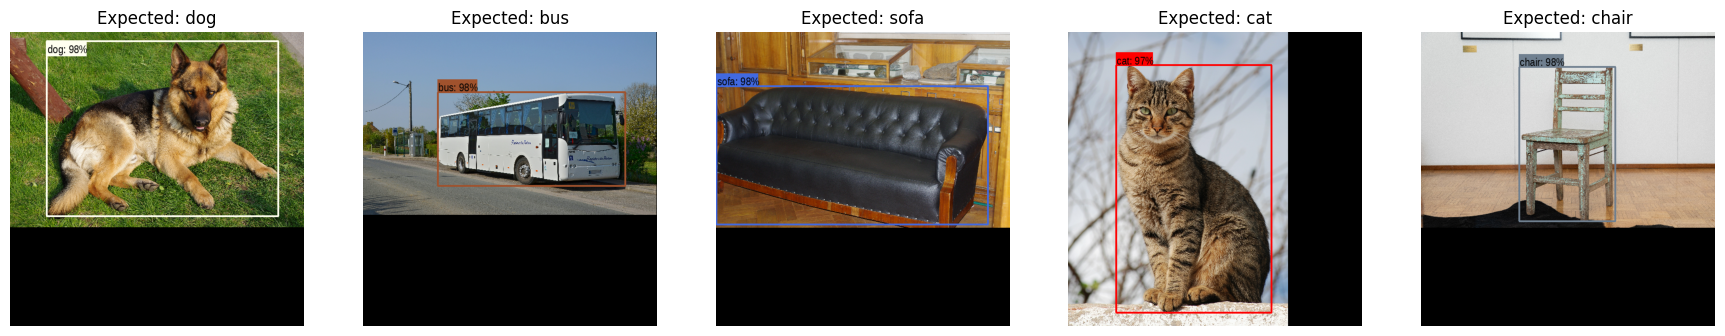

In [ ]:
from PIL import Image, ImageColor, ImageDraw, ImageFont

def display_image(image):
    fig = plt.figure(figsize=(20, 15))
    plt.grid(False)
    plt.imshow(image)
    plt.axis("off")

def draw_bounding_box_on_image(
    image,
    ymin, xmin, ymax, xmax,
    color, font,
    thickness=4,
    display_str_list=()
):
    """Adds a bounding box to an image. Coordinates are normalized [0,1]."""
    draw = ImageDraw.Draw(image)
    im_width, im_height = image.size

    (left, right, top, bottom) = (xmin * im_width, xmax * im_width,
                                  ymin * im_height, ymax * im_height)

    draw.line([(left, top), (left, bottom), (right, bottom),
               (right, top), (left, top)],
              width=thickness, fill=color)

    display_str_heights = [font.getbbox(ds)[3] for ds in display_str_list]
    total_display_str_height = (1 + 2 * 0.05) * sum(display_str_heights)

    if top > total_display_str_height:
        text_bottom = top
    else:
        text_bottom = top + total_display_str_height

    for display_str in display_str_list[::-1]:
        bbox = font.getbbox(display_str)
        text_width, text_height = bbox[2], bbox[3]
        margin = np.ceil(0.05 * text_height)

        draw.rectangle([(left, text_bottom - text_height - 2 * margin),
                        (left + text_width, text_bottom)],
                       fill=color)

        draw.text((left + margin, text_bottom - text_height - margin),
                  display_str, fill="black", font=font)

        text_bottom -= text_height - 2 * margin

def draw_boxes_normalized(image_np, boxes_yxyx_norm, class_ids, scores,
                          max_boxes=50, min_score=0.30):
    """Overlay labeled boxes on an image (normalized yxyx)."""
    colors = list(ImageColor.colormap.values())
    try:
        font = ImageFont.truetype(
            "/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Regular.ttf",
            25
        )
    except Exception:
        font = ImageFont.load_default()

    image_pil = Image.fromarray(np.uint8(image_np)).convert("RGB")

    drawn = []
    for i in range(min(len(scores), max_boxes)):
        if scores[i] < min_score:
            continue

        ymin, xmin, ymax, xmax = boxes_yxyx_norm[i]
        cls_id = int(class_ids[i])
        cls_name = ID_TO_CLASS.get(cls_id, str(cls_id))
        display_str = "{}: {}%".format(cls_name, int(100 * float(scores[i])))

        color = colors[hash(cls_name) % len(colors)]
        draw_bounding_box_on_image(
            image_pil, ymin, xmin, ymax, xmax,
            color=color, font=font,
            display_str_list=[display_str],
            thickness=4,
        )
        drawn.append((cls_name, float(scores[i])))

    return np.array(image_pil), drawn



CONF_TH = 0.30
H = W = 640.0

resized_uint8 = tf.cast(tf.clip_by_value(batch, 0, 255), tf.uint8).numpy()

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
all_detected = []

for i, ax in enumerate(axes):
    boxes_xywh = np.array(preds["boxes"][i])       
    classes = np.array(preds["classes"][i])        
    conf = np.array(preds["confidence"][i])       

    keep = conf >= CONF_TH
    boxes_xywh = boxes_xywh[keep]
    classes = classes[keep]
    conf = conf[keep]

    x = boxes_xywh[:, 0]
    y = boxes_xywh[:, 1]
    w = boxes_xywh[:, 2]
    h = boxes_xywh[:, 3]

    xmin = x
    ymin = y
    xmax = x + w
    ymax = y + h

    # clip to image bounds
    xmin = np.clip(xmin, 0, W)
    xmax = np.clip(xmax, 0, W)
    ymin = np.clip(ymin, 0, H)
    ymax = np.clip(ymax, 0, H)

    boxes_yxyx_norm = np.stack([ymin/H, xmin/W, ymax/H, xmax/W], axis=-1)

    vis, det_list = draw_boxes_normalized(
        resized_uint8[i], boxes_yxyx_norm, classes, conf,
        max_boxes=50, min_score=CONF_TH
    )
    all_detected.append(det_list)

    ax.imshow(vis)
    ax.axis("off")
    ax.set_title(f"Expected: {expected_labels[i]}")

plt.show()

In [100]:
def contains_expected(det_list, expected_name):
    for name, score in det_list:
        if name == expected_name:
            return True, score
    return False, None

for i, expected_name in enumerate(expected_labels):
    det_list = all_detected[i]

    print("=" * 70)
    print(f"Image {i+1} | Expected class: {expected_name} (id={CLASS_TO_ID[expected_name]})")
    if len(det_list) == 0:
        print("No detections above threshold.")
        continue

    found, score = contains_expected(det_list, expected_name)
    print(f"Expected detected? {found}" + (f" (confidence={score:.3f})" if found else ""))

    print("\nTop detections:")
    for name, s in det_list[:10]:
        print(f"- {name:12s}  conf={s:.3f}")

Image 1 | Expected class: dog (id=11)
Expected detected? True (confidence=0.990)

Top detections:
- dog           conf=0.990
Image 2 | Expected class: bus (id=5)
Expected detected? True (confidence=0.988)

Top detections:
- bus           conf=0.988
Image 3 | Expected class: sofa (id=17)
Expected detected? True (confidence=0.981)

Top detections:
- sofa          conf=0.981
Image 4 | Expected class: cat (id=7)
Expected detected? True (confidence=0.979)

Top detections:
- cat           conf=0.979
Image 5 | Expected class: chair (id=8)
Expected detected? True (confidence=0.985)

Top detections:
- chair         conf=0.985
